# BetweenFactor

`BetweenFactor<VALUE>` represents a measurement of the relative transformation between two variables of the same Lie-group type. Common examples are `BetweenFactorPose2` for 2D odometry and `BetweenFactorPose3` for 3D odometry or relative-pose measurements.

If the factor connects values $X_1$ and $X_2$ and the measurement is $Z$, its unwhitened residual is

$$ r(X_1, X_2; Z) = \operatorname{Local}\left(Z, \operatorname{Between}(X_1, X_2)\right). $$

Here $\operatorname{Between}(X_1,X_2)=X_1^{-1}X_2$ is the predicted relative transformation. For a Lie group whose origin chart uses the exponential and logarithm maps, this becomes

$$ r(X_1, X_2; Z) = \operatorname{Log}\left(Z^{-1}X_1^{-1}X_2\right). $$

The noise model whitens this residual, and the resulting scalar loss contributes to the graph's objective. `BetweenConstraint<VALUE>` is a derived class that uses a constrained noise model to enforce the relative transformation exactly.

GTSAM Copyright 2010-2022, Georgia Tech Research Corporation,
Atlanta, Georgia 30332-0415
All Rights Reserved

Authors: Frank Dellaert, et al. (see THANKS for the full author list)

See LICENSE for the license information

<a href="https://colab.research.google.com/github/borglab/gtsam/blob/develop/gtsam/slam/doc/BetweenFactor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
try:
    import google.colab
    %pip install --quiet gtsam-develop
except ImportError:
    pass

In [2]:
import gtsam
import numpy as np
from gtsam import BetweenFactorPose2, BetweenFactorPose3
from gtsam import Pose2, Pose3, Rot3, Point3
from gtsam import NonlinearFactorGraph, Values
from gtsam import symbol_shorthand
import graphviz

X = symbol_shorthand.X

## Noise model and coordinate frame

Suppose $X_1={}^WT_A$ and $X_2={}^WT_B$ are poses of frames $A$ and $B$ in a world frame $W$. The measured relative pose is

$$ Z={}^AT_B=X_1^{-1}X_2. $$

The transform $Z$ is expressed in frame $A$: for example, its translation is the origin of $B$ written in $A$ coordinates. The covariance passed to `BetweenFactor`, however, is the covariance of the local residual $r$, not a covariance of the matrix entries or pose parameters used to construct $Z$.

GTSAM uses a right-hand retraction. A local perturbation around the measurement is therefore

$$ \operatorname{Retract}_Z(\eta)=Z\,\operatorname{Retract}_I(\eta), $$

or, for an exponential-map chart, $Z\operatorname{Exp}(\eta)$. Consequently, for `Pose2`, `Pose3`, `Rot2`, and `Rot3`, $\eta$ and its covariance are expressed in the local axes of the second (target) frame $B$. The statement that the residual is represented in the tangent space at the identity describes its algebraic representation; the right-hand retraction determines its physical coordinate frame.

For `Pose3`, tangent vectors and covariance matrices use the order $[\omega_x,\omega_y,\omega_z,\rho_x,\rho_y,\rho_z]$: rotation first, then translation. The rotational components are local axis-angle increments, not roll, pitch, and yaw. `Pose2` uses $[\delta x,\delta y,\delta\theta]$. Also note that `noiseModel.Diagonal.Sigmas` expects standard deviations; use `Variances` or `Gaussian.Covariance` when starting from variances or a full covariance matrix.

If a covariance $\Sigma_A$ instead describes a left-hand perturbation in the source frame, convert it before constructing the factor:

$$ \Sigma_B = \operatorname{Ad}_{Z^{-1}}\,\Sigma_A\,\operatorname{Ad}_{Z^{-1}}^T. $$

Likewise, a covariance expressed in Euler angles or another pose parameterization must be propagated through the Jacobian from those parameters to GTSAM's local coordinates.

In [ ]:
# A right-hand perturbation is recovered directly as the factor residual.
measurement = Pose3(
    Rot3.RzRyRx(0.2, -0.1, 0.3), Point3(1.0, 0.5, -0.2)
)
delta_b = np.array([0.01, -0.02, 0.03, 0.10, -0.05, 0.02])
predicted_relative = measurement.retract(delta_b)

pose_a = Pose3(Rot3.Yaw(0.4), Point3(2.0, -1.0, 0.5))
pose_b = pose_a.compose(predicted_relative)
unit_noise_6 = gtsam.noiseModel.Unit.Create(6)
frame_factor = BetweenFactorPose3(X(10), X(11), measurement, unit_noise_6)
frame_values = Values()
frame_values.insert(X(10), pose_a)
frame_values.insert(X(11), pose_b)

computed_delta_b = frame_factor.unwhitenedError(frame_values)
np.testing.assert_allclose(computed_delta_b, delta_b, atol=1e-9)
print("Target-frame perturbation:", computed_delta_b)

## Creating a BetweenFactor

You create a `BetweenFactor` by specifying:
1.  The keys of the two variables it connects (e.g., `X(0)`, `X(1)`).
2.  The measured relative transformation (e.g., a `Pose2` or `Pose3`).
3.  A noise model describing the uncertainty of the measurement.

In [3]:
# Example for Pose2 (2D SLAM odometry)
key1 = X(0)
key2 = X(1)
measured_pose2 = Pose2(1.0, 0.0, 0.0) # Move 1 meter forward
odometry_noise = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.2, 0.2, 0.1]))

between_factor_pose2 = BetweenFactorPose2(key1, key2, measured_pose2, odometry_noise)
between_factor_pose2.print("BetweenFactorPose2: ")

# Example for Pose3 (3D SLAM odometry)
measured_pose3 = Pose3(Rot3.Yaw(0.1), Point3(0.5, 0, 0)) # Move 0.5m forward, yaw 0.1 rad
odometry_noise_3d = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.05, 0.05, 0.05, 0.1, 0.1, 0.1]))

between_factor_pose3 = BetweenFactorPose3(X(1), X(2), measured_pose3, odometry_noise_3d)
between_factor_pose3.print("\nBetweenFactorPose3: ")

BetweenFactorPose2: BetweenFactor(x0,x1)
  measured:  (1, 0, 0)
  noise model: diagonal sigmas [0.2; 0.2; 0.1];

BetweenFactorPose3: BetweenFactor(x1,x2)
  measured:  R: [
	0.995004165, -0.0998334166, 0;
	0.0998334166, 0.995004165, 0;
	0, 0, 1
]
t: 0.5   0   0
  noise model: diagonal sigmas [0.05; 0.05; 0.05; 0.1; 0.1; 0.1];


## Evaluating the Error

`unwhitenedError(values)` returns the vector residual defined above. `whitenedError(values)` applies the noise model and also returns a vector. In contrast, `error(values)` returns the scalar loss contributed by the factor; for a Gaussian noise model this is one half of the squared norm of the whitened residual.

In [ ]:
values = Values()
values.insert(X(0), Pose2(0.0, 0.0, 0.0))
values.insert(X(1), Pose2(1.1, 0.1, 0.05)) # Slightly off from measurement

# Reproduce the factor's local-coordinate residual.
pose0 = values.atPose2(X(0))
pose1 = values.atPose2(X(1))
predicted_relative = pose0.between(pose1)
unwhitened_expected = measured_pose2.localCoordinates(predicted_relative)
unwhitened = between_factor_pose2.unwhitenedError(values)
whitened = between_factor_pose2.whitenedError(values)
scalar_loss = between_factor_pose2.error(values)

sigmas = odometry_noise.sigmas()
whitened_expected = unwhitened_expected / sigmas
np.testing.assert_allclose(unwhitened, unwhitened_expected)
np.testing.assert_allclose(whitened, whitened_expected)
np.testing.assert_allclose(scalar_loss, 0.5 * whitened @ whitened)

print(f"Unwhitened residual: {unwhitened}")
print(f"Whitened residual: {whitened}")
print(f"Scalar factor loss: {scalar_loss}")

## Visualization

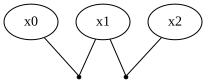

In [5]:
graph = NonlinearFactorGraph()
graph.add(between_factor_pose2)
graph.add(between_factor_pose3)

dot_string = graph.dot(values)
graphviz.Source(dot_string)